In [1]:
import requests
import pandas as pd

df = pd.read_csv(r"C:\Projects\Tisini\Visualization\Leagues Tornaments Friendlies\Equity\Men\Equity FC 2025-26 Player Analysis with Per 90.csv")

In [2]:
df.head

<bound method NDFrame.head of               Player              Position  Passes Complete  \
0          Abdi Abdi              Fullback            316.0   
1       Barrack Dago           Centre Back            413.0   
2       Bernard Lusi           Centre Back           1121.0   
3        Bevex David                Winger            246.0   
4     Bramwel Simiyu               Striker             41.0   
5       Dark Janafil            Midfielder             56.0   
6          Deng Kang                Winger             62.0   
7        Edward Olak            Goalkeeper             30.0   
8     Elvis Odhiambo            Midfielder            421.0   
9   Frederick Iyanza                Winger            122.0   
10      George Kamau  Attacking Midfielder            734.0   
11       Henry Obala            Midfielder             53.0   
12       Isaac Owiyo              Fullback            518.0   
13    Josiah Timpati  Attacking Midfielder             47.0   
14    Mainge Muthoka     

In [3]:
df.shape

(43, 60)

In [4]:
df.columns

Index(['Player', 'Position', 'Passes Complete', 'Passes Incomplete',
       'Pass Accuracy %', 'Goals', 'Assists', 'Shots (in+out box)',
       'Fouls Committed', 'Yellow Cards', 'Red Cards', 'Tackles Won',
       'Tackles Lost', 'Total Tackles', 'Tackle Success Rate %',
       'Tackles Won /90', 'Tackles Lost /90', 'Interceptions',
       'Interceptions /90', 'Crosses Attempted', 'Crosses Complete',
       'Cross Accuracy %', 'Crosses Attempted /90', 'Crosses Complete /90',
       'Ball Won Opp', 'Ball Won Own', 'Ball Own Lost', 'Ball Opp Lost',
       'Dribbles', 'Box Carry', 'Box Touch', 'Progressive Passes Complete',
       'Progressive Passes Incomplete', 'Estimated Minutes', 'Matches',
       'Estimated Starts', 'Estimated Sub Apps', 'Estimated 90s',
       'Passes Complete /90', 'Passes Incomplete /90', 'Goals /90',
       'Assists /90', 'Shots (in+out box) /90', 'Fouls Committed /90',
       'Ball Won Opp /90', 'Ball Won Own /90', 'Ball Own Lost /90',
       'Ball Opp Lost /90'

In [36]:
# Create a separate dataframe for defensive analysis
att_df = df[
    [
        "Player",
        "Position",
        "Estimated Minutes",
        "Estimated 90s",
        
        # Attack
        "Goals /90",
        "Assists /90",
        "Chances Created",
        "Key Pass",
        "Progressive Passes Complete /90",
        "Progressive Passes Incomplete /90",
        "Dribbles /90",
        "Box Carry /90",
        "Box Touch /90",

        # Interceptions
        "Interceptions /90",
        
        # Defensive actions
        "Clearances",
        "Blocks",
        
        # Possession recovery
        "Ball Won Opp /90",
        "Ball Opp Lost /90",
        
        # Aerials
        "Aerial Duels Won",
        "Aerial Duels Total",
        "Aerial Duels %",
    ]
].copy()

# Minimum playing-time filter
MIN_MINUTES = 1000

att_df_MIN = att_df[
    att_df["Estimated Minutes"] >= MIN_MINUTES
].copy()

In [37]:
# Create per-90 defensive metrics that are not already provided

att_df["Chances Created /90"] = (att_df["Chances Created"] / att_df["Estimated 90s"])

att_df["Key Pass /90"] = (att_df["Key Pass"] / att_df["Estimated 90s"])

# Apply the same calculations to the MIN_MINUTE minute dataset
att_df_MIN["Chances Created /90"] = (att_df["Chances Created"] / att_df["Estimated 90s"])

att_df_MIN["Key Pass /90"] = (att_df["Key Pass"] / att_df["Estimated 90s"])

# Display Check the new metrics
att_df_MIN[
    [
        "Player",
        "Chances Created /90",
        "Key Pass /90"
    ]
].round(2).head()

,Player,Chances Created /90,Key Pass /90
0,Abdi Abdi,0.91,0.52
1,Barrack Dago,0.13,0.00
2,Bernard Lusi,0.41,0.32
3,Bevex David,0.70,0.60
8,Elvis Odhiambo,0.33,0.33


One important decision

We're deliberately not using raw totals such as Clearances or Blocks on the radar. We've converted those to per-90 values, making the comparison much fairer.

Next, we'll take these eight metrics and convert them into 0–100 percentile scores among the selected comparison group (def_df_400 for now).

That's where the radar starts becoming genuinely useful.

In [40]:
# Metrics used for the attacking radar

attacking_metrics = {
    "Goals": "Goals /90",
    "Assists": "Assists /90",
    "Chance Creation": "Chances Created /90",
    "Key Passes": "Key Pass /90",
    "Progressive Passing": "Progressive Passes Complete /90",
    "Dribbling": "Dribbles /90",
    "Box Carry": "Box Carry /90",
    "Box Touch": "Box Touch /90"
}

print("Attacking radar metrics:")
for label, column in attacking_metrics.items():
    print(f"{label}: {column}")

Attacking radar metrics:
Goals: Goals /90
Assists: Assists /90
Chance Creation: Chances Created /90
Key Passes: Key Pass /90
Progressive Passing: Progressive Passes Complete /90
Dribbling: Dribbles /90
Box Carry: Box Carry /90
Box Touch: Box Touch /90


In [41]:
# Create a copy for percentile calculations
radar_df = att_df_MIN.copy()

# Calculate percentile scores for each defensive metric
for label, column in attacking_metrics.items():
    radar_df[f"{label} Score"] = (radar_df[column].rank(pct=True) * 100)

# Score columns
score_columns = [f"{label} Score" for label in attacking_metrics]

# Inspect the scores
radar_df[["Player"] + score_columns].round(1).head()

,Player,Goals Score,Assists Score,Chance Creation Score,Key Passes Score,Progressive Passing Score,Dribbling Score,Box Carry Score,Box Touch Score
0,Abdi Abdi,53.1,18.8,75.0,75.0,68.8,71.9,75.0,65.6
1,Barrack Dago,40.6,50.0,18.8,6.2,31.2,18.8,28.1,18.8
2,Bernard Lusi,62.5,40.6,56.2,62.5,81.2,50.0,28.1,75.0
3,Bevex David,93.8,75.0,68.8,81.2,25.0,93.8,93.8,87.5
8,Elvis Odhiambo,18.8,62.5,43.8,68.8,59.4,71.9,81.2,65.6


In [42]:
from mplsoccer import Radar

# Radar labels
params = list(attacking_metrics.keys())

# Radar scale
low = [0] * len(params)
high = [100] * len(params)

# Select player by name
player_name = "Michael Onyango"

player_data = radar_df[radar_df["Player"] == player_name].iloc[0]

# Extract player's percentile scores
values = [player_data[f"{metric} Score"] for metric in params]

# Check the values
print(f"Player: {player_name}")
print()

for param, value in zip(params, values):
    print(f"{param}: {value:.1f}")

Player: Michael Onyango

Goals: 18.8
Assists: 18.8
Chance Creation: 12.5
Key Passes: 18.8
Progressive Passing: 6.2
Dribbling: 18.8
Box Carry: 28.1
Box Touch: 18.8


In [43]:
# Inspect all position values in the 400+ minute dataset
position_counts = (radar_df["Position"].value_counts(dropna=False))

position_counts

Position
Midfielder              4
Fullback                3
Centre Back             3
Winger                  3
Attacking Midfielder    1
Goalkeeper              1
Striker                 1
Name: count, dtype: int64

In [45]:
# Positions included in the defensive comparison
positions = ["Winger", "Attacking Midfielder", "Striker"]

# Filter to defenders only
defenders_df = radar_df[radar_df["Position"].isin(positions)].copy()

# Check the result
print(f"Attackers with {MIN_MINUTES}+ minutes: {len(defenders_df)}")
print()

print(defenders_df["Position"].value_counts())

Attackers with 1000+ minutes: 5

Position
Winger                  3
Attacking Midfielder    1
Striker                 1
Name: count, dtype: int64


In [26]:
defenders_df[["Player", "Position", "Estimated Minutes"]].sort_values("Estimated Minutes", ascending=False)

,Player,Position,Estimated Minutes
16,Rashid Moyo,Striker,2934.2
10,George Kamau,Attacking Midfielder,2835.1
3,Bevex David,Winger,1801.0
14,Mainge Muthoka,Winger,1124.2
23,Wayne Mureithi,Winger,1042.7


In [46]:
# Defender-only radar dataset
radar_df = att_df_MIN[att_df_MIN["Position"].isin(positions)].copy()

# Calculate percentile scores within defenders only
for label, column in attacking_metrics.items():
    radar_df[f"{label} Score"] = (radar_df[column].rank(pct=True) * 100)

# Score columns
score_columns = [f"{label} Score" for label in attacking_metrics]

# View defender scores
radar_df[["Player", "Position"] + score_columns].round(1)

,Player,Position,Goals Score,Assists Score,Chance Creation Score,Key Passes Score,Progressive Passing Score,Dribbling Score,Box Carry Score,Box Touch Score
3,Bevex David,Winger,80.0,60.0,40.0,40.0,60.0,80.0,80.0,60.0
10,George Kamau,Attacking Midfielder,60.0,80.0,80.0,100.0,100.0,60.0,40.0,40.0
14,Mainge Muthoka,Winger,20.0,100.0,100.0,80.0,40.0,40.0,20.0,20.0
16,Rashid Moyo,Striker,100.0,40.0,20.0,20.0,20.0,20.0,60.0,100.0
23,Wayne Mureithi,Winger,40.0,20.0,60.0,60.0,80.0,100.0,100.0,80.0


In [47]:
# Display defender percentile scores

display(radar_df[["Player", "Position"] + score_columns].sort_values("Player").round(1))

,Player,Position,Goals Score,Assists Score,Chance Creation Score,Key Passes Score,Progressive Passing Score,Dribbling Score,Box Carry Score,Box Touch Score
3,Bevex David,Winger,80.0,60.0,40.0,40.0,60.0,80.0,80.0,60.0
10,George Kamau,Attacking Midfielder,60.0,80.0,80.0,100.0,100.0,60.0,40.0,40.0
14,Mainge Muthoka,Winger,20.0,100.0,100.0,80.0,40.0,40.0,20.0,20.0
16,Rashid Moyo,Striker,100.0,40.0,20.0,20.0,20.0,20.0,60.0,100.0
23,Wayne Mureithi,Winger,40.0,20.0,60.0,60.0,80.0,100.0,100.0,80.0


In [48]:
from mplsoccer import Radar
import matplotlib.pyplot as plt

# Radar parameters
params = list(defensive_metrics.keys())

# Percentile scale
low = [0] * len(params)
high = [100] * len(params)

# Create the radar
radar = Radar(
    params=params,
    min_range=low,
    max_range=high,
    round_int=[False] * len(params),
    num_rings=4,
    ring_width=1,
    center_circle_radius=1
)

print("Radar created successfully.")

Radar created successfully.


In [49]:
# Calculate the average percentile score across all defenders

defender_average = [radar_df[f"{metric} Score"].mean() for metric in params]

# Display the benchmark
for metric, value in zip(params, defender_average):
    print(f"{metric}: {value:.1f}")

Goals: 60.0
Assists: 60.0
Chance Creation: 60.0
Key Passes: 60.0
Progressive Passing: 60.0
Dribbling: 60.0
Box Carry: 60.0
Box Touch: 60.0


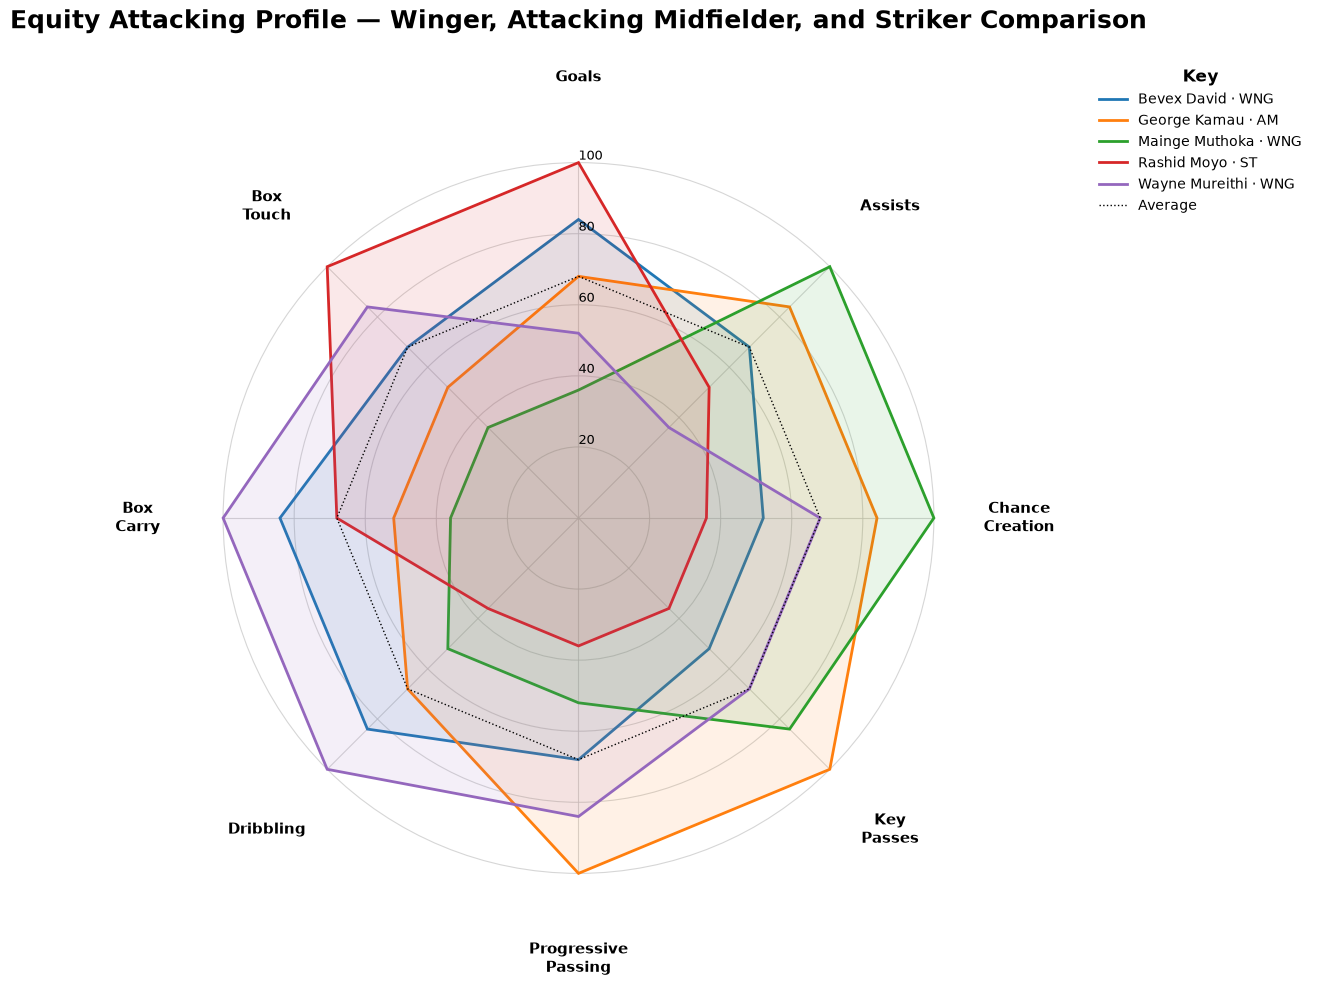

In [78]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle

fig, ax = radar.setup_axis()

plt.rcParams["font.family"] = "sans-serif"

# Colours for each defender
colors = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b"
]


legend_items = []


# --------------------------------
# Draw the Lines
# --------------------------------

# Draw subtle lines connecting the center to each metric
for x, y in zip(radar.rotation_sin, radar.rotation_cos):
    ax.plot(
        [0, x * radar.outer_ring],
        [0, y * radar.outer_ring],
        linewidth=0.8,
        color="#cccccc",
        alpha=0.8,
        zorder=0
    )

# --------------------------------
# Draw the radar rings ONCE
# --------------------------------

# Draw subtle inner grid circles only
for radius in [1, 2, 3, 4, 5]:
    ax.add_patch(
        Circle(
            (0, 0),
            radius,
            fill=False,
            linewidth=0.8,
            edgecolor="#cccccc",
            alpha=0.8
        )
    )

# --------------------------------
# Draw individual defenders
# --------------------------------

position_abbr = {
    "Centre Back": "CB",
    "Fullback": "FB",
    "Winger": "WNG",
    "Attacking Midfielder": "AM",
    "Striker": "ST"
}

for i, (_, player) in enumerate(radar_df.iterrows()):

    values = [player[f"{metric} Score"] for metric in params]

    # Light filled polygon
    radar._draw_radar(
        values,
        ax=ax,
        facecolor=colors[i],
        edgecolor="none",
        alpha=0.1
    )

    # Strong polygon outline
    radar._draw_radar(
        values,
        ax=ax,
        facecolor="none",
        edgecolor=colors[i],
        linewidth=2
    )

    legend_items.append(
        Line2D(
            [0],
            [0],
            color=colors[i],
            linewidth=2,
            label=f'{player["Player"]} · {position_abbr[player["Position"]]}'
        )
    )

# --------------------------------
# Draw profile average
# --------------------------------

radar._draw_radar(
    defender_average,
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1,
    linestyle=":"
)

legend_items.append(
    Line2D(
        [0],
        [0],
        color="black",
        linewidth=1,
        linestyle=":",
        label="Average"
    )
)

# --------------------------------
# Legend
# --------------------------------

legend = ax.legend(
    handles=legend_items,
    loc="upper left",
    bbox_to_anchor=(1.05, 1),
    frameon=False,
    title="Key"
)

legend.get_title().set_fontweight("bold")
legend.get_title().set_fontsize(12)

ax.set_title(
    "Equity Attacking Profile — Winger, Attacking Midfielder, and Striker Comparison",
    fontsize=18,
    pad=20,
    fontweight="bold"
)

# Add metric labels around the radar
# Straight, stacked metric labels

param_radius = radar.outer_ring + 1.2

param_xs = param_radius * radar.rotation_sin
param_ys = param_radius * radar.rotation_cos

for label, x, y in zip(params, param_xs, param_ys):
    ax.text(
        x,
        y,
        label.replace(" ", "\n"),
        fontsize=11,
        fontweight="bold",
        ha="center",
        va="center",
        rotation=0
    )

# Add percentile/range labels
for value in [20, 40, 60, 80, 100]:
    radius = radar.outer_ring * (value/100)

    ax.text(
        0,
        radius,
        str(value),
        fontsize=9,
        ha="left",
        va="bottom"
    )

plt.show()